# DS4FE — Reconstructing the SPX Volatility Surface from Raw End-of-Day Option Quotes

```text
# the whole thing:
raw call/put mids
   -> put-call parity regression (per expiry)
      -> forward F + rate r
         -> Black-76 root-find on each mid
            -> implied vol sigma
               -> interpolate onto the 7x9 grid

# 1. use put-call parity to infer the forward F (and rate r)
# 2. plug that forward into Black-76
# 3. invert Black-76 to get the IV
```

starting from the raw end-of-day (15:45 ET) bid/ask quotes for SPX options

it rebuilds the entire implied-volatility surface from scratch, for one underlying, with no external forward / dividend / interest-rate curve.

The only assumptions are **no-arbitrage** (put-call parity gives the forward and rate) and **European exercise** (Black-76, which is exact for SPX). Everything else is bootstrapped from the option prices themselves.

Databento gives **option prices, not IV**

The data lives in `data/iv/` in four layers:

| Layer | Files | What |
|---|---|---|
| 1. Raw quotes | `cbbo_YYYY-MM-DD_1545.parquet` | OPRA bid/ask snapshot at 15:45 ET |
| 2. Definitions | `def_YYYY-MM-DD.parquet` | strike, expiry, call/put per contract |
| 3. Computed IV | `iv_YYYY-MM-DD.parquet` | one row per option, with reconstructed IV |
| 4. Surface matrix | `surfaces.parquet` (523×63) | one row per day on a fixed 7×9 grid |

Source: `OPRA.PILLAR`, parent `SPX.OPT`. Only the 15:45 minute was pulled (cost ~\$0.017/day, ~\$9 for 2 years of daily surfaces).


1. **Ordinary least squares (per expiry).** Put–call parity is the exact identity $C(K)-P(K)=e^{-rT}(F-K)$. Treating it as a simple linear regression of the observed $C(K)-P(K)$ on strike $K$, the **slope** estimates $-e^{-rT}$ and the **intercept** estimates $e^{-rT}F$, which we invert to get the discount factor, the rate $r$, and the forward $F$. We report the regression **$R^2$ as a goodness-of-fit / data-quality diagnostic** (it is ≈ 1 because no-arbitrage makes the relationship near-deterministic).

2. **One-dimensional root-finding.** Black-76 maps a volatility to an option price monotonically; recovering the implied volatility $\sigma$ from each observed mid-price is a scalar root-find (Brent's method). There is no closed form, so this is solved numerically per option.

3. **Interpolation onto a fixed grid.** The scattered $(\text{maturity},\text{moneyness},\sigma)$ points are interpolated — linearly in total variance $w=\sigma^2T$ along maturity, linearly in log-moneyness along the smile — onto a common 7×9 grid so that every trading day becomes a comparable 63-dimensional vector.

No external rate, dividend, or volatility data is used: $F$, $r$, and $\sigma$ are all estimated from the option prices themselves.

In [1]:
import os, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import cm

sys.path.append(os.path.abspath('experiments/iv_surface'))
import iv_lib

IV = 'data/iv'
DAY = '2023-06-01'           # a validated example day
asof = pd.Timestamp(DAY)
print('walking through', DAY)

walking through 2023-06-01


## Layer 1 — Raw option quotes (Databento Data)

A single consolidated BBO snapshot at 15:45 ET. Each row is a quote for one `instrument_id`; prices are already in dollars (`.to_df()` is pre-scaled).

In [2]:
cbbo = pd.read_parquet(f'{IV}/cbbo_{DAY}_1545.parquet')
print('raw snapshot shape:', cbbo.shape)
qcols = [c for c in ['instrument_id','bid_px_00','ask_px_00','bid_sz_00','ask_sz_00'] if c in cbbo.columns]
cbbo[qcols].head(10)

raw snapshot shape: (5436, 15)


,instrument_id,bid_px_00,ask_px_00,bid_sz_00,ask_sz_00
ts_recv,,,,,
2023-06-01 19:45:00+00:00,587232586,3206.5,3222.50,15,15
2023-06-01 19:45:00+00:00,587210169,0.0,0.05,0,1226
2023-06-01 19:45:00+00:00,587202639,3106.7,3122.70,15,15
2023-06-01 19:45:00+00:00,587202654,0.0,0.05,0,1221
2023-06-01 19:45:00+00:00,587240025,3007.0,3023.00,15,15
2023-06-01 19:45:00+00:00,587202614,0.0,0.05,0,750
2023-06-01 19:45:00+00:00,587217645,2907.2,2923.20,15,15
2023-06-01 19:45:00+00:00,587210232,0.0,0.05,0,1221
2023-06-01 19:45:00+00:00,587210235,2807.5,2823.50,15,15


## Layer 2 — Contract definitions

The quotes only carry an `instrument_id`. The definitions file maps that id to the **strike**, **expiration**, and **call/put** flag we need to price the option.

In [3]:
defs = pd.read_parquet(f'{IV}/def_{DAY}.parquet')
dcols = [c for c in ['instrument_id','raw_symbol','strike_price','expiration','instrument_class'] if c in defs.columns]
print('definitions shape:', defs.shape)
defs[dcols].head(20)

definitions shape: (5436, 64)


,instrument_id,raw_symbol,strike_price,expiration,instrument_class
ts_recv,,,,,
2023-06-01 10:30:00.471877849+00:00,587202563,SPX 231215C02950000,2950.0,2023-12-15 00:00:00+00:00,C
2023-06-01 10:30:00.471877849+00:00,587202561,SPX 231215C04300000,4300.0,2023-12-15 00:00:00+00:00,C
2023-06-01 10:30:00.479962037+00:00,587202564,SPX 231215C02775000,2775.0,2023-12-15 00:00:00+00:00,C
2023-06-01 10:30:00.479962037+00:00,587202565,SPX 231215P04400000,4400.0,2023-12-15 00:00:00+00:00,P
2023-06-01 10:30:00.487905732+00:00,587202567,SPX 231215C06000000,6000.0,2023-12-15 00:00:00+00:00,C
2023-06-01 10:30:00.487905732+00:00,587202566,SPX 231215P04050000,4050.0,2023-12-15 00:00:00+00:00,P
2023-06-01 10:30:00.487917064+00:00,587202569,SPX 231215C06100000,6100.0,2023-12-15 00:00:00+00:00,C
2023-06-01 10:30:00.487917064+00:00,587202568,SPX 231215P03975000,3975.0,2023-12-15 00:00:00+00:00,P
2023-06-01 10:30:00.487925798+00:00,587202571,SPX 231215P03575000,3575.0,2023-12-15 00:00:00+00:00,P


## Layer 3 — Reconstructing IV (the core step)

Three sub-steps, done per expiry:

1. **Join + mid price.** Merge quotes with definitions, keep valid two-sided quotes, take `mid = (bid+ask)/2`.
2. **Recover forward F and rate r from put–call parity.** We do *not* assume a forward or borrow a rate curve — we fit them from the option prices themselves:
   $$C(K)-P(K) = e^{-rT}(F-K)$$
   Regressing call−put on strike gives slope $b=-e^{-rT}$ and intercept $a=e^{-rT}F$, so $r=-\ln(-b)/T$ and $F=a/(-b)$.
3. **Invert Black-76** for each option's mid to get $\sigma$ (Brent root-find).

First, build the merged mid-price table:

In [4]:
snap = cbbo.sort_index()
px = snap.groupby('instrument_id').last().reset_index()
bid_col = 'bid_px_00' if 'bid_px_00' in px.columns else 'bid_px'
ask_col = 'ask_px_00' if 'ask_px_00' in px.columns else 'ask_px'
px = px[['instrument_id', bid_col, ask_col]].rename(columns={bid_col:'bid', ask_col:'ask'})

dmap = defs[['instrument_id','strike_price','expiration','instrument_class']].drop_duplicates('instrument_id').copy()
dmap['strike'] = dmap['strike_price'].astype(float)
dmap['is_call'] = dmap['instrument_class'].astype(str).str.upper().str[0] == 'C'
dmap['expiry'] = pd.to_datetime(dmap['expiration']).dt.tz_localize(None).dt.normalize()

df = px.merge(dmap, on='instrument_id', how='inner')
df = df[(df.bid > 0) & (df.ask > 0) & (df.ask >= df.bid)].copy()
df['mid'] = 0.5*(df.bid + df.ask)
df['T'] = (df.expiry - asof).dt.days / 365.25
df = df[df['T'] > 0]
print('priceable options today:', len(df), '| expiries:', df.expiry.nunique())
df[['instrument_id','expiry','T','strike','is_call','mid']].head(6)

priceable options today: 5303 | expiries: 17


,instrument_id,expiry,T,strike,is_call,mid
0,587202561,2023-12-15,0.539357,4300.0,True,197.25
1,587202563,2023-12-15,0.539357,2950.0,True,1337.45
2,587202564,2023-12-15,0.539357,2775.0,True,1503.30
3,587202565,2023-12-15,0.539357,4400.0,False,230.90
4,587202566,2023-12-15,0.539357,4050.0,False,121.45
5,587202567,2023-12-15,0.539357,6000.0,True,0.20


expiry 2023-09-15  T=0.290y
fitted forward  F = 4,265.0
fitted rate     r = 5.41%   (discount factor 0.9844)


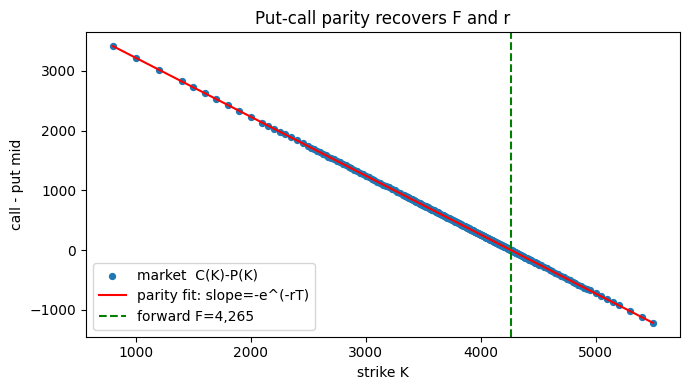

In [5]:
# --- pick one expiry and recover F, r from put-call parity ---
exp = sorted(df.expiry.unique())[3]          # a mid-dated expiry
g = df[df.expiry == exp]
piv = g.pivot_table(index='strike', columns='is_call', values='mid').dropna()
K = piv.index.values.astype(float)
diff = (piv[True] - piv[False]).values        # C - P
b, a = np.polyfit(K, diff, 1)
disc = -b
T = float(g['T'].iloc[0])
F = a / disc

r = -np.log(disc) / T

print(f'expiry {pd.Timestamp(exp).date()}  T={T:.3f}y')
print(f'fitted forward  F = {F:,.1f}')
print(f'fitted rate     r = {r*100:.2f}%   (discount factor {disc:.4f})')

fig, ax = plt.subplots(figsize=(7,4))
ax.scatter(K, diff, s=18, label='market  C(K)-P(K)')
ax.plot(K, a + b*K, 'r-', label=f'parity fit: slope=-e^(-rT)')
ax.axvline(F, ls='--', color='green', label=f'forward F={F:,.0f}')
ax.set_xlabel('strike K'); ax.set_ylabel('call - put mid'); ax.legend(); ax.set_title('Put-call parity recovers F and r')
plt.tight_layout(); plt.show()


1. The `bid > 0` filter drops them automatically — we never feed a one-sided quote into the math.
2. Put-call parity only needs strikes where **both the call and the put have a real two-sided quote**. Those are the strikes **near the money**, which on SPX are extremely liquid (tight bid-ask, size on both sides). So the parity fit is built from the *good* part of the book and ignores the junk wings.

The cell below quantifies this for the whole day: how many quotes are two-sided, how many strikes are paired per expiry, and — the thing that makes the line so straight — the **R² of the parity fit** (how close to a perfect line the points lie). R² ≈ 1.0 means the no-arbitrage relationship holds almost exactly, which is the real reason your plot looked so clean.

In [6]:
# ===== DATA-QUALITY TEST: is the book liquid enough for the parity fit? =====
raw = px.merge(dmap, on='instrument_id', how='inner')
n_total   = len(raw)
n_zerobid = int((raw.bid <= 0).sum())
n_valid   = int(((raw.bid > 0) & (raw.ask > 0) & (raw.ask >= raw.bid)).sum())
print('--- quote quality (whole day) ---')
print(f'instruments quoted     : {n_total}')
print(f'valid two-sided quotes : {n_valid} ({n_valid/n_total:.1%})')
print(f'zero / empty bid (wings): {n_zerobid} ({n_zerobid/n_total:.1%})  <- dropped automatically')

# Per-expiry: paired strikes + straightness (R^2) of the put-call parity line
rows = []
for exp_, gg in df.groupby('expiry'):
    pv = gg.pivot_table(index='strike', columns='is_call', values='mid').dropna()
    n_pair = len(pv)
    if n_pair < 2:
        rows.append((exp_, n_pair, np.nan, False)); continue
    Kk = pv.index.values.astype(float)
    yy = (pv[True] - pv[False]).values
    bb, aa = np.polyfit(Kk, yy, 1)
    yhat = aa + bb * Kk
    ss_res = ((yy - yhat) ** 2).sum(); ss_tot = ((yy - yy.mean()) ** 2).sum()
    r2 = 1 - ss_res / ss_tot if ss_tot > 0 else np.nan
    rows.append((exp_, n_pair, r2, (n_pair >= 4) and (bb < 0)))

q = pd.DataFrame(rows, columns=['expiry', 'paired_strikes', 'parity_R2', 'passes_filter'])
print('\n--- parity fit per expiry ---')
print(f'expiries available           : {len(q)}')
print(f'expiries passing filter      : {int(q.passes_filter.sum())}  (>=4 paired strikes & negative slope)')
print(f'median paired strikes/expiry : {q.paired_strikes.median():.0f}')
print(f'parity-fit R^2  min={q.parity_R2.min():.5f}  median={q.parity_R2.median():.6f}  (1.0 = perfectly straight line)')
print('\nVERDICT: near-1.0 R^2 on every expiry => the no-arbitrage line holds almost exactly => data is sufficient.')

q_disp = q.copy(); q_disp['expiry'] = q_disp['expiry'].dt.date
q_disp

--- quote quality (whole day) ---
instruments quoted     : 5436
valid two-sided quotes : 5303 (97.6%)
zero / empty bid (wings): 133 (2.4%)  <- dropped automatically

--- parity fit per expiry ---
expiries available           : 17
expiries passing filter      : 17  (>=4 paired strikes & negative slope)
median paired strikes/expiry : 122
parity-fit R^2  min=1.00000  median=1.000000  (1.0 = perfectly straight line)

VERDICT: near-1.0 R^2 on every expiry => the no-arbitrage line holds almost exactly => data is sufficient.


,expiry,paired_strikes,parity_R2,passes_filter
0,2023-06-16,266,0.999999,True
1,2023-07-21,281,1.000000,True
2,2023-08-18,264,1.000000,True
3,2023-09-15,257,1.000000,True
4,2023-10-20,197,1.000000,True
5,2023-11-17,199,1.000000,True
6,2023-12-15,153,1.000000,True
7,2024-01-19,117,1.000000,True
8,2024-02-16,121,1.000000,True
9,2024-03-15,123,1.000000,True


### Where does Black-76 actually happen?

So far we've only used **put-call parity** a volatility-free identity  to get the forward `F` and rate `r`. **No volatility yet.** Black-76 enters in the *next* step, when we turn each option's price into an implied vol.

`iv_lib` has two functions and they are inverses of each other:

| function | direction | given → output |
|---|---|---|
| `black76_price(F, K, T, sigma, r, is_call)` | forward | a vol → a **price** |
| `implied_vol(price, F, K, T, r, is_call)` | inverse | a **price** → the vol |

`implied_vol` can't be solved with a formula, so it calls `black76_price` repeatedly inside a root-finder (`brentq`) until the model price matches the market mid. The cell below makes this explicit on a single ATM option: invert its price to get `sigma`, then feed that `sigma` back into `black76_price` and check we recover the original market mid.

In [7]:
# ===== WHERE BLACK-76 HAPPENS: invert one ATM option, then re-price to verify =====
calls = g[g.is_call].copy()
i_atm = (calls.strike - F).abs().idxmin()        # call nearest the forward
atm = calls.loc[i_atm]

# STEP 1 (inverse): price -> implied vol  [this is the Black-76 root-find]
sigma = iv_lib.implied_vol(atm.mid, F, atm.strike, T, r, atm.is_call)

# STEP 2 (forward): feed sigma back into Black-76 -> should reproduce the price
reprice = iv_lib.black76_price(F, atm.strike, T, sigma, r, atm.is_call)

print(f'ATM call:  K = {atm.strike:,.0f}   F = {F:,.1f}   T = {T:.3f}y   r = {r*100:.2f}%')
print(f'market mid price              : {atm.mid:.3f}')
print(f'implied_vol(price)  -> sigma  : {sigma:.4f}  ({sigma*100:.2f}% vol)   <-- Black-76 inverted here')
print(f'black76_price(sigma) -> price : {reprice:.3f}')
print(f'round-trip error              : {abs(reprice - atm.mid):.2e}   (~0 => inversion is correct)')

# The full smile = doing exactly this STEP 1 for every strike in the expiry.

ATM call:  K = 4,265   F = 4,265.0   T = 0.290y   r = 5.41%
market mid price              : 128.900
implied_vol(price)  -> sigma  : 0.1429  (14.29% vol)   <-- Black-76 inverted here
black76_price(sigma) -> price : 128.900
round-trip error              : 1.72e-06   (~0 => inversion is correct)


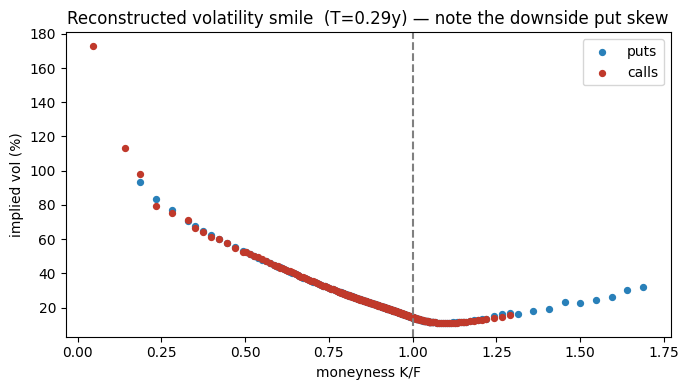

In [8]:
# --- invert Black-76 for every option in this expiry -> the smile ---
g = g.copy()
g['iv'] = [iv_lib.implied_vol(row.mid, F, row.strike, T, r, row.is_call) for row in g.itertuples()]
g['moneyness'] = g.strike / F
sm = g.dropna(subset=['iv']).sort_values('moneyness')

fig, ax = plt.subplots(figsize=(7,4))
for flag, lab, c in [(False,'puts','#2980B9'), (True,'calls','#C0392B')]:
    s = sm[sm.is_call == flag]
    ax.scatter(s.moneyness, s.iv*100, s=18, color=c, label=lab)
ax.axvline(1.0, ls='--', color='grey')
ax.set_xlabel('moneyness K/F'); ax.set_ylabel('implied vol (%)')
ax.set_title(f'Reconstructed volatility smile  (T={T:.2f}y) — note the downside put skew')
ax.legend(); plt.tight_layout(); plt.show()

The whole day's table (all expiries) is produced by `iv_lib.build_iv_table` and cached as `iv_YYYY-MM-DD.parquet`. Let's load the cached result and confirm it matches:

In [9]:
iv = pd.read_parquet(f'{IV}/iv_{DAY}.parquet')
print('computed IV table:', iv.shape, '| columns:', list(iv.columns))
print('\nforward curve by expiry:')
print(iv.groupby('T')[['F','r']].first().round({'F':1,'r':4}))
iv.head(6)

computed IV table: (5220, 9) | columns: ['expiry', 'T', 'strike', 'F', 'r', 'moneyness', 'is_call', 'mid', 'iv']

forward curve by expiry:
               F       r
T                       
0.041068  4222.9  0.0609
0.136893  4240.2  0.0548
0.213552  4252.3  0.0542
0.290212  4265.0  0.0541
0.386037  4282.7  0.0538
0.462697  4294.5  0.0537
0.539357  4306.5  0.0533
0.635181  4325.1  0.0531
0.711841  4337.5  0.0528
0.788501  4347.5  0.0522
0.884326  4362.7  0.0515
0.960986  4372.3  0.0509
1.056810  4384.4  0.0502
1.555099  4440.2  0.0462
2.551677  4530.6  0.0404
3.548255  4624.6  0.0376
4.544832  4721.7  0.0366


,expiry,T,strike,F,r,moneyness,is_call,mid,iv
0,2023-06-16,0.041068,3975.0,4222.858871,0.060886,0.941305,True,252.35,0.201570
1,2023-06-16,0.041068,2700.0,4222.858871,0.060886,0.639377,False,0.15,0.720611
2,2023-06-16,0.041068,3450.0,4222.858871,0.060886,0.816982,False,0.95,0.420008
4,2023-06-16,0.041068,4475.0,4222.858871,0.060886,1.059709,False,252.00,0.127732
5,2023-06-16,0.041068,2850.0,4222.858871,0.060886,0.674898,False,0.20,0.654970
6,2023-06-16,0.041068,3700.0,4222.858871,0.060886,0.876184,False,1.85,0.317261


## Layer 4 — The final surface matrix

Each day's scattered (T, moneyness, IV) points are interpolated onto a **fixed 7×9 grid** (7 maturities 30–365d × 9 moneyness 0.85–1.15) so every day is a comparable 63-vector. Stacking 523 days gives `surfaces.parquet`.

### Does the data actually support this grid? (coverage across all 523 days)

We just defined the 7×9 grid — 7 maturities (30–365d) that each day's scattered IV points are interpolated onto. Natural question: across the **whole 2-year sample**, does the raw option data contain enough expiries *inside* that 30–365d window to interpolate, or are we extrapolating?

The key number is **how many expiries fall inside the grid's maturity window** each day — those are the *anchors* the 7 target tenors are interpolated between. With ~11 anchors versus 7 targets, the maturity axis is densely sampled, so the 7 tenors are interpolated between real expiries on essentially every day (with only a small short-end exception, quantified below).

- **in-window anchors** = listed expiries with 30 ≤ days-to-expiry ≤ 365 (these build the surface)
- **below 30d** = ultra-short expiries (used as the lower anchor for the 30d point)
- **above 365d** = the multi-year LEAPS that fall outside the grid window (kept in the raw/IV tables, not in the 7×9 surface)

days covered             : 523   (2021-06-01 -> 2023-06-30)
listed expiries / day    : mean 18.5  median 19   range [15, 21]
anchors in 30-365d window: mean 11.0  median 11   range [10, 12]   (>= 7 targets on every day)
below 30d (short anchor) : mean 0.97 / day
above 365d (LEAPS, excl.): mean 6.5  median 7
shortest / longest expiry: median 15d / 1743d (4.8y)
extrapolation needed     : long end (max < 365d) 0 days  |  short end (min > 30d) 26 days (5%, 30d target mildly extrapolated; worst case 36d)


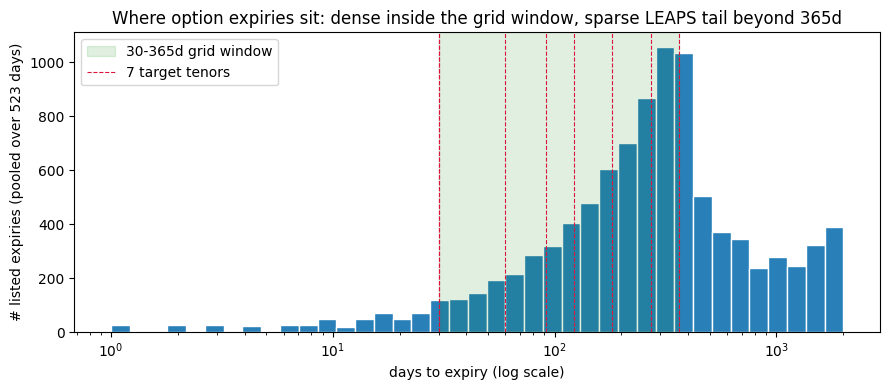

In [10]:
# ===== Full 523-day expiry coverage =====
import glob
WIN_LO, WIN_HI = 30, 365                       # the grid's maturity window (days)
TARGETS = [30, 60, 91, 122, 182, 273, 365]     # the 7 maturities we interpolate onto
cov_rows, all_days = [], []
for f in sorted(glob.glob(f'{IV}/iv_*.parquet')):
    Td = np.sort(pd.read_parquet(f, columns=['T'])['T'].unique()) * 365.25
    all_days.append(Td)
    cov_rows.append({
        'date': os.path.basename(f)[3:13],
        'n_exp':      len(Td),
        'n_in':       int(((Td >= WIN_LO) & (Td <= WIN_HI)).sum()),
        'n_below30':  int((Td < WIN_LO).sum()),
        'n_above365': int((Td > WIN_HI).sum()),
        'min_d': Td.min(), 'max_d': Td.max(),
    })
cov = pd.DataFrame(cov_rows); cov['date'] = pd.to_datetime(cov['date'])
all_days = np.concatenate(all_days)

n_short = int((cov.min_d > WIN_LO).sum())       # days whose nearest expiry is already > 30d
print(f'days covered             : {len(cov)}   ({cov.date.min().date()} -> {cov.date.max().date()})')
print(f'listed expiries / day    : mean {cov.n_exp.mean():.1f}  median {cov.n_exp.median():.0f}   range [{cov.n_exp.min()}, {cov.n_exp.max()}]')
print(f'anchors in 30-365d window: mean {cov.n_in.mean():.1f}  median {cov.n_in.median():.0f}   range [{cov.n_in.min()}, {cov.n_in.max()}]   (>= 7 targets on every day)')
print(f'below 30d (short anchor) : mean {cov.n_below30.mean():.2f} / day')
print(f'above 365d (LEAPS, excl.): mean {cov.n_above365.mean():.1f}  median {cov.n_above365.median():.0f}')
print(f'shortest / longest expiry: median {cov.min_d.median():.0f}d / {cov.max_d.median():.0f}d ({cov.max_d.median()/365:.1f}y)')
print(f'extrapolation needed     : long end (max < 365d) {(cov.max_d < WIN_HI).sum()} days  |  '
      f'short end (min > 30d) {n_short} days ({n_short/len(cov):.0%}, 30d target mildly extrapolated; worst case {cov.min_d.max():.0f}d)')

# One meaningful figure: where every listed expiry actually sits, pooled over all 523 days (log maturity axis)
fig, ax = plt.subplots(figsize=(9, 4))
bins = np.logspace(np.log10(all_days.min()), np.log10(all_days.max()), 40)
ax.hist(all_days, bins=bins, color='#2980B9', edgecolor='w')
ax.axvspan(WIN_LO, WIN_HI, color='green', alpha=0.12, label='30-365d grid window')
for t in TARGETS:
    ax.axvline(t, ls='--', color='crimson', lw=0.8)
ax.axvline(TARGETS[0], ls='--', color='crimson', lw=0.8, label='7 target tenors')
ax.set_xscale('log')
ax.set_xlabel('days to expiry (log scale)'); ax.set_ylabel('# listed expiries (pooled over 523 days)')
ax.set_title('Where option expiries sit: dense inside the grid window, sparse LEAPS tail beyond 365d')
ax.legend(); plt.tight_layout(); plt.show()

In [11]:
import json
grid = json.load(open(f'{IV}/surface_grid.json'))
MATS = np.array(grid['mats_days']); MONEY = np.array(grid['moneyness'])
surf = pd.read_parquet(f'{IV}/surfaces.parquet').sort_index()
print('surface matrix:', surf.shape, '(days x grid points)')
print('date range:', surf.index.min().date(), '->', surf.index.max().date())
print('maturities (days):', MATS.tolist())
print('moneyness:', MONEY.tolist())

# one day's ATM term structure
row = surf.loc[DAY] if DAY in surf.index.astype(str).tolist() else surf.iloc[-1]
atm = [row[f'T{m}_m1000']*100 for m in MATS]
print('\nATM term structure on', DAY, ':', [f'{m}d={v:.1f}%' for m,v in zip(MATS, atm)])

surface matrix: (523, 63) (days x grid points)
date range: 2021-06-01 -> 2023-06-30
maturities (days): [30, 60, 91, 122, 182, 273, 365]
moneyness: [0.85, 0.9, 0.95, 0.975, 1.0, 1.025, 1.05, 1.1, 1.15]

ATM term structure on 2023-06-01 : ['30d=12.8%', '60d=13.4%', '91d=14.1%', '122d=14.7%', '182d=15.6%', '273d=16.3%', '365d=16.8%']


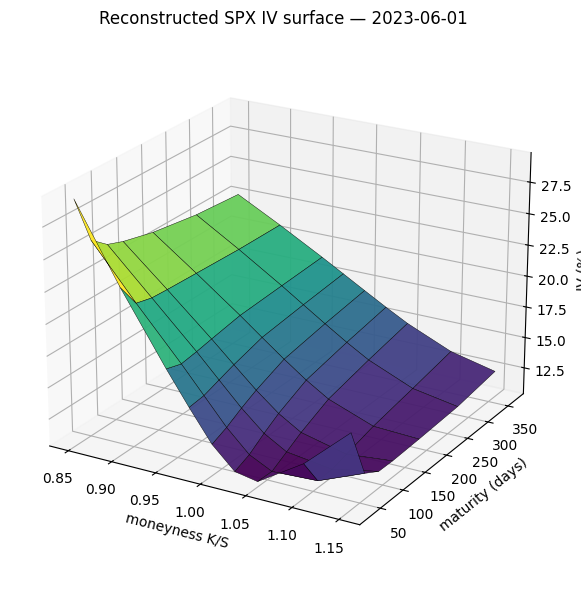

In [12]:
# 3D view of this day's reconstructed surface
Z = row.values.reshape(len(MATS), len(MONEY)) * 100
MX, MY = np.meshgrid(MONEY, MATS)
fig = plt.figure(figsize=(9,6))
ax = fig.add_subplot(111, projection='3d')
ax.plot_surface(MX, MY, Z, cmap=cm.viridis, edgecolor='k', lw=0.3, alpha=0.95)
ax.set_xlabel('moneyness K/S'); ax.set_ylabel('maturity (days)'); ax.set_zlabel('IV (%)')
ax.set_title(f'Reconstructed SPX IV surface — {DAY}'); ax.view_init(elev=22, azim=-60)
plt.tight_layout(); plt.show()